# Domains labeling

When running `model.assign_domains`, the output domains are identified only by opaque IDs such as `D1003`, `L4`, and similar IDs. While sufficient for computation, these identifiers are difficult to interpret biologically.

In practice, it is often preferable to replace them with biologically meaningful annotations such as 'Tertiary Lymphoid Structure' or 'Necrotic Tumor'.

This tutorial demonstrates a two-stage workflow for assigning interpretable domain names:

1. Automated pre-annotation using an LLM (guided by extracted marker signals per domain).
2. Biology-guided manual review (optional but recommended) to validate and refine the proposed labels.


In [1]:
import novae

## Get the spatial domains

Here, we assume you already ran `model.assign_domains`. If not, refer to the other tutorials, e.g. the [main usage tutorial](../main_usage) until you have your (unlabeled) spatial domains.

For the sake of the tutorial, we load a dataset that was pre-annotated:


In [2]:
adata = novae.load_dataset("Xenium_V1_hPancreas_Cancer_Add_on_FFPE_outs", annotations=True)[0]

[INFO] (novae.data._load._hf) Found 1 h5ad file(s) matching the filters.


Note that this `AnnData` object already contains the following keys in `adata.obs`:

- `cell_type` and `cell_type_level1`: a coarse and a detailed cell-type annotation (we used [scConcept](https://github.com/theislab/scConcept) and a [CELLxGENE](https://cellxgene.cziscience.com/) reference dataset).
- `novae_domains_res0.8` and `novae_domains_res1`: novae domains (unlabeled), obtained in zero-shot mode with a `resolution=0.8` and `resolution=1` respectively.


In [3]:
adata.obs.columns[-4:].tolist()

['cell_type', 'cell_type_level1', 'novae_domains_res0.8', 'novae_domains_res1']

We see the domains are named `L0` to `L7`. We would like to provide meaningful labels instead!


In [4]:
adata.obs["novae_domains_res1"].value_counts()

novae_domains_res1
L0    45299
L5    26733
L3    25777
L4    24055
L2    23553
L6    22224
L1    13647
L7     9666
Name: count, dtype: int64

## Automated labeling

You can use [`novae.label_domains`](../../api/label/#novae.label_domains) to generate a DataFrame mapping each domain ID to a domain label.

### API key setup

An API key is required to use this function. You can either provide it directly as an `api_key` argument to [`novae.label_domains`](../../api/label/#novae.label_domains), or set it as an environment variable (`OPENAI_API_KEY` for OpenAI, `ANTHROPIC_API_KEY` for Anthropic).

> If you just want to generate the prompt without making an API call, set `return_prompt=True` and no API key will be required. You can then copy/paste the generated `messages` and `output_schema` into your preferred LLM playground.

For this example, we decided to load an `OPENAI_API_KEY` variable that we saved in a `.env` file:


In [5]:
import dotenv

dotenv.load_dotenv("./.env")

True

### LLM call

Then, we can actually run the labeling. Internally, it uses an LLM that is prompted with descriptive information: DEGs per domain, domain sizes, and optionally pathway expressions or cell-type proportions.

See more details in the [API](../../api/label/#novae.label_domains) on how to add pathway/cell-type information or LLM arguments.


In [6]:
df_labels = novae.label_domains(
    adata,
    "novae_domains_res1",  # the column in adata.obs containing the domain IDs to label
    tissue="pancreas-cancer",  # optional context (tissue or disease name)
    species="human",  # optional context (species name)
)

It creates a DataFrame with a label associated to each domain ID and a confidence score:


In [7]:
df_labels

,label,confidence_score
novae_domains_res1,,
L5,Reactive Stroma,0.95
L3,Peritumoral Immune Aggregate,0.92
L1,Desmoplastic Stroma,0.90
L6,Inflammatory Ductal Interface,0.92
L2,Ductal Tumor Region,0.89
L0,Acinar Cell Compartment,0.98
L4,Transitional Ductal Zone,0.88
L7,Endocrine Islet Niche,0.98


Afterwards, you can use this DataFrame to map each domain ID to the corresponding domain label:


In [8]:
adata.obs["novae_domains_labeled"] = adata.obs["novae_domains_res1"].map(df_labels["label"])

And plot the results:


/Users/quentinblampey/dev/novae/novae/plot/_spatial.py:78: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


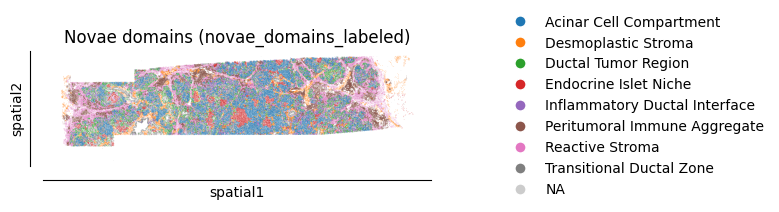

In [9]:
novae.plot.domains(adata, obs_key="novae_domains_labeled")

### Usage on multiple slides

If you have multiple slides, you still need to run `novae.label_domains` only once, since Novae was designed to retreive the same domains across slides. Simply choose to run `novae.label_domains` on a representative slide (i.e., containing all domains), and then apply the `.map` for each slide.


In [ ]:
adatas = ...  # multiple AnnData / slides
adata_representative = ...  # on slide among the list

# run once (on the representative slide)
df_labels = novae.label_domains(adata_representative, "novae_domains_res1")

for adata in adatas:
    adata.obs["novae_domains_labeled"] = adata.obs["novae_domains_res1"].map(df_labels["label"])

## Manual review

We recommend to validate and refine the proposed labels. This requires biological knowledge, but allows a greater confidence in the resulting labels.

For the sake of the tutorial, we show it on another slide - as an extra example - but the steps apply to any slides / tissues.


In [6]:
adata = novae.load_dataset("Xenium_V1_Human_Colon_Cancer_P5_CRC_Add_on_FFPE_outs", annotations=True)[0]

[INFO] (novae.data._load._hf) Found 1 h5ad file(s) matching the filters.


We run the automated labeling as a first step, as detailed above.


/Users/quentinblampey/dev/novae/novae/plot/_spatial.py:78: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


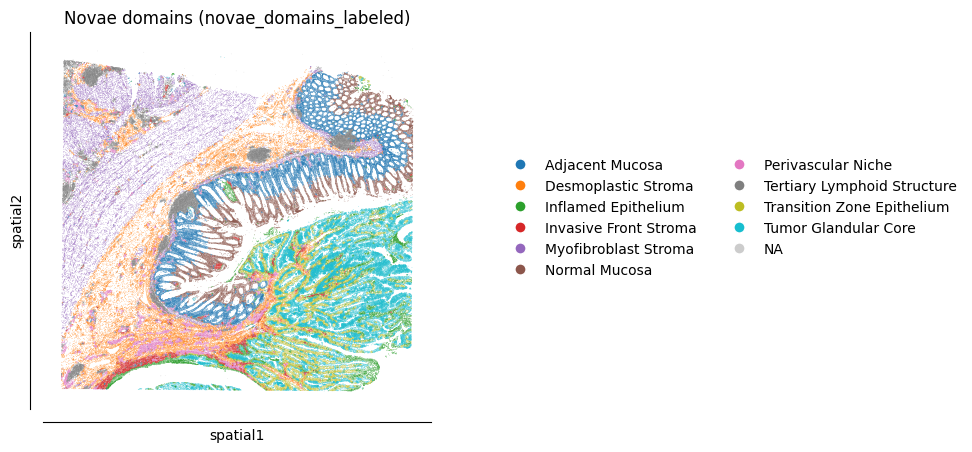

In [7]:
df_labels = novae.label_domains(
    adata,
    "novae_domains_res1",  # the column in adata.obs containing the domain IDs to label
    tissue="colorectal-cancer",  # optional context (tissue or disease name)
    species="human",  # optional context (species name)
    cell_type_key="cell_type_level1",  # optional column in adata.obs containing cell type annotations to use as additional context
)

adata.obs["novae_domains_labeled"] = adata.obs["novae_domains_res1"].map(df_labels["label"])

novae.plot.domains(adata, obs_key="novae_domains_labeled")

In [9]:
df_labels

,label,confidence_score
novae_domains_res1,,
L5,Tertiary Lymphoid Structure,0.95
L9,Invasive Front Stroma,0.92
L2,Reactive Stroma,0.91
L4,Desmoplastic Stroma,0.93
L8,Germinal Center Niche,0.89
L0,Mucosal Gland Epithelium,0.97
L7,Inflamed Epithelium,0.87
L1,Tumor Core Epithelium,0.99
L6,Proliferative Tumor Margin,0.94


### Cell-type composition

Assuming you already ran cell-type annotation, one interesting thing to do is to check the cell-type composition of each domain.

On this dataset, we already ran cell-type annotation, and we have a column called `cell_type_level1`.

We can easily compute the cell-type proportion within each domain:


In [13]:
groups = adata.obs.groupby("novae_domains_res1", observed=True)
df_props = groups["cell_type_level1"].value_counts(normalize=True).unstack()

df_props

cell_type_level1,B and B plasma,Endothelial,Epithelial,Mesenchymal,Myeloid,Neural,T and NK cells
novae_domains_res1,,,,,,,
L0,0.141632,0.026559,0.717715,0.072249,0.031694,0.000884,0.009267
L1,0.002747,0.000655,0.993931,0.000878,0.000751,0.000000,0.001038
L2,0.094843,0.065708,0.032305,0.679914,0.079036,0.017351,0.030842
L3,0.117413,0.013672,0.803124,0.032026,0.028794,0.000083,0.004889
L4,0.096874,0.162963,0.027239,0.552982,0.124729,0.005747,0.029467
L5,0.389644,0.064428,0.061465,0.259155,0.101846,0.001140,0.122322
L6,0.036377,0.056368,0.750891,0.129122,0.021384,0.000000,0.005858
L7,0.061372,0.058181,0.653922,0.133423,0.084141,0.000061,0.008899
L8,0.351294,0.128712,0.057042,0.338283,0.089385,0.001911,0.033373


This can be visualized nicely via a heatmap:

> To better visualize the differences in proportions across domains, we scaled again the data, and set `vmin` and `vmax`.


<Axes: xlabel='cell_type_level1', ylabel='novae_domains_res1'>

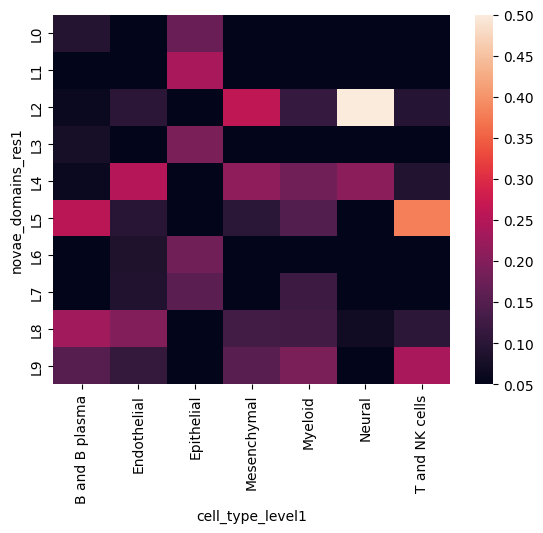

In [14]:
import seaborn as sns

sns.heatmap(df_props / df_props.sum(0), vmax=0.5, vmin=0.05)

### Marker genes

Extracting differentially expressed genes (DEGs) per domains also helps a lot in this manual review.


In [10]:
import scanpy as sc

sc.tl.rank_genes_groups(adata, "novae_domains_res1")

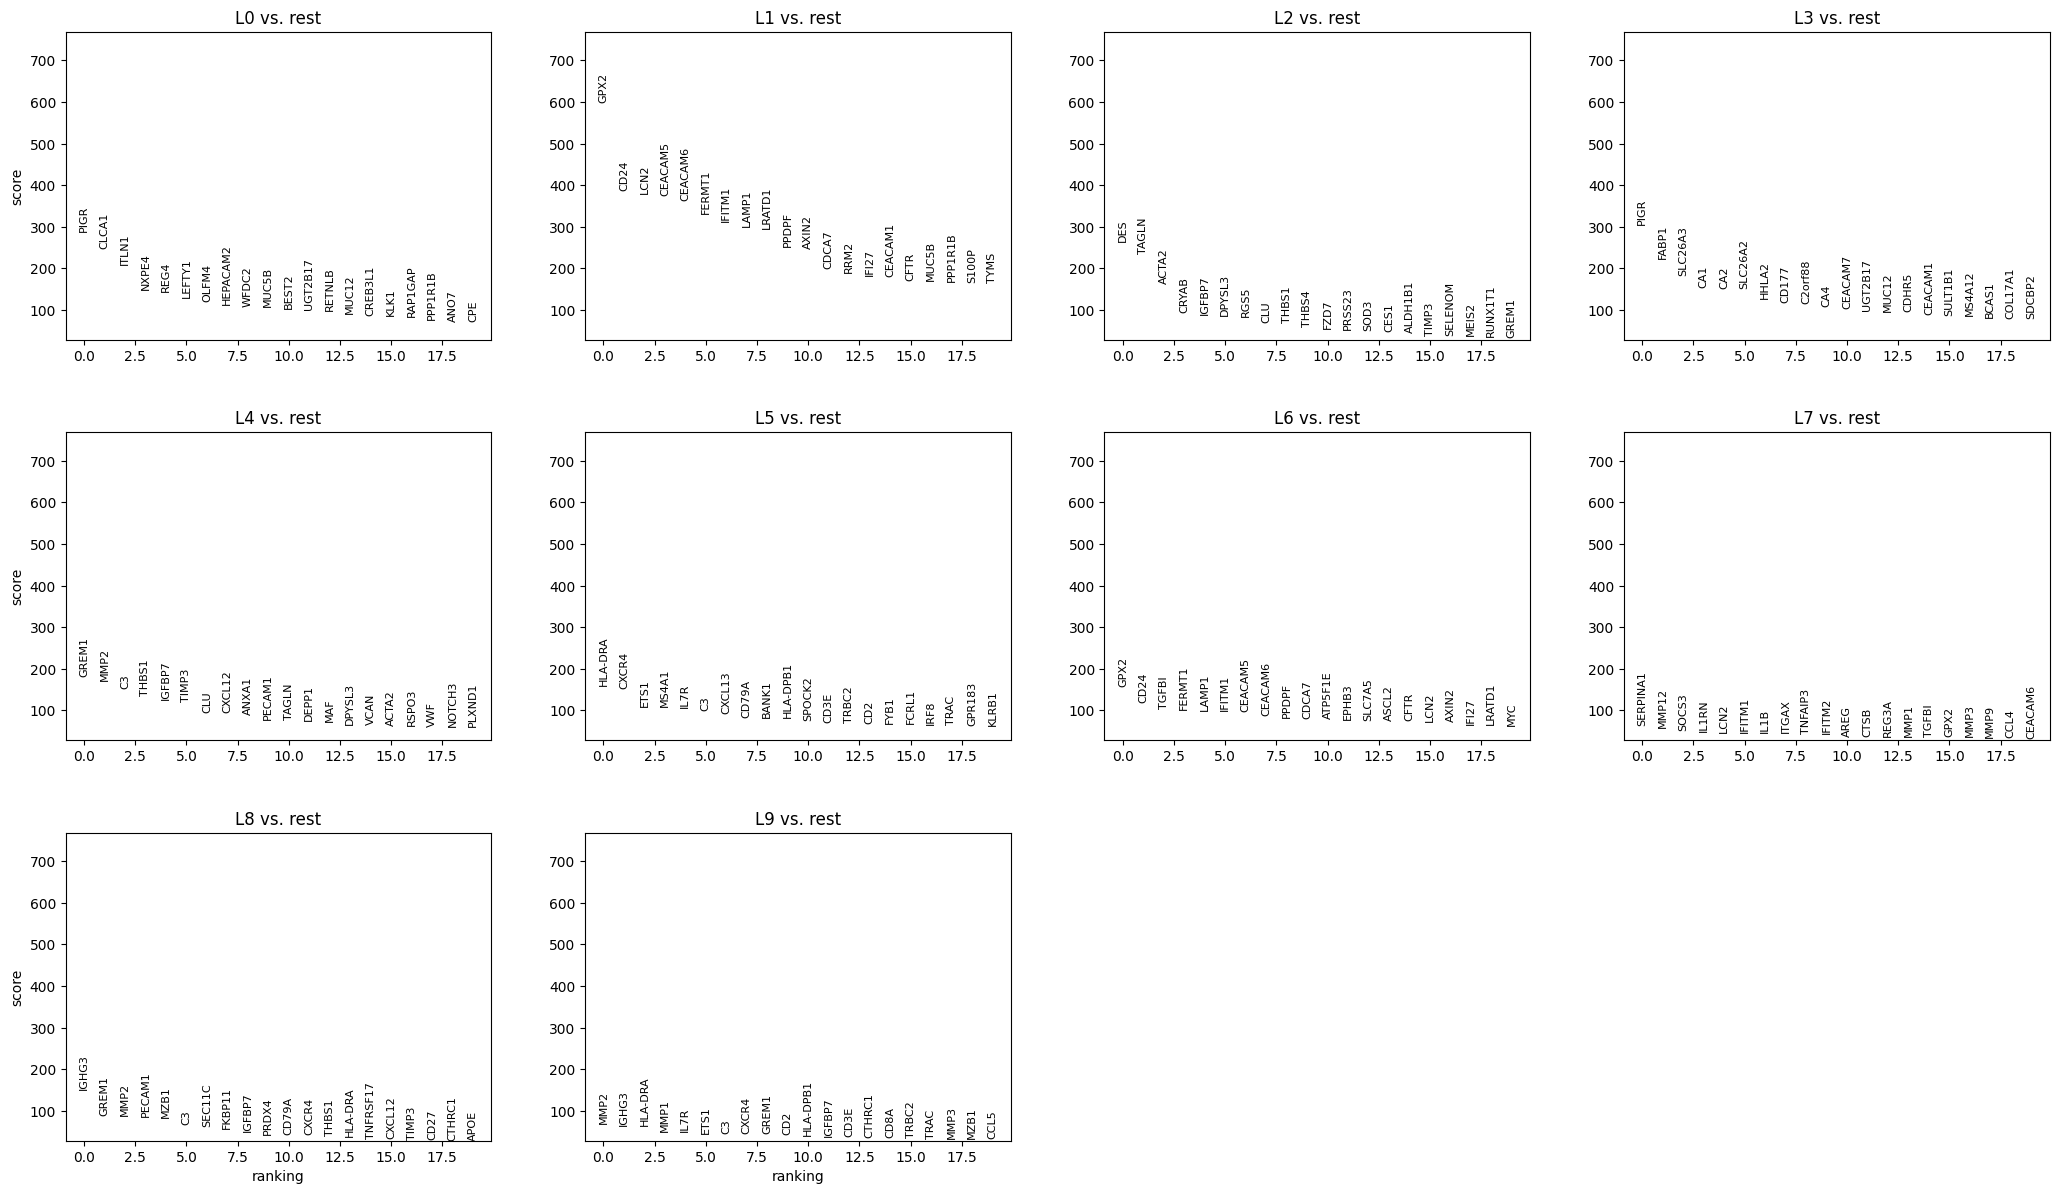

In [11]:
sc.pl.rank_genes_groups(adata)

In [47]:
sc.tl.rank_genes_groups(adata, "novae_domains_res1", groups=["L6", "L1"], reference="L1")

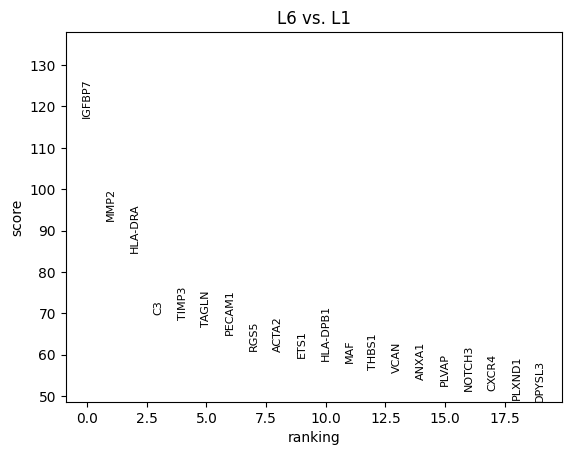

In [28]:
sc.pl.rank_genes_groups(adata)

### Updating the labels

Based on our observations, we can update the label DataFrame:


In [27]:
df_labels.loc["L3", "label"] = "..."

df_labels

,label,confidence_score
novae_domains_res1,,
L5,Tertiary Lymphoid Structure,0.98
L9,Invasive Front Stroma,0.90
L2,Myofibroblast-rich Stroma,0.95
L4,Reactive Stroma,0.93
L8,Immune-rich Stroma,0.91
L0,Mucinous Compartment,0.97
L7,Inflamed Stroma,0.92
L1,Proliferative Tumor Core,0.99
L6,Crypt Tumor Base,0.96


And re-run the mapping from the original domain IDs:


/Users/quentinblampey/dev/novae/novae/plot/_spatial.py:78: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


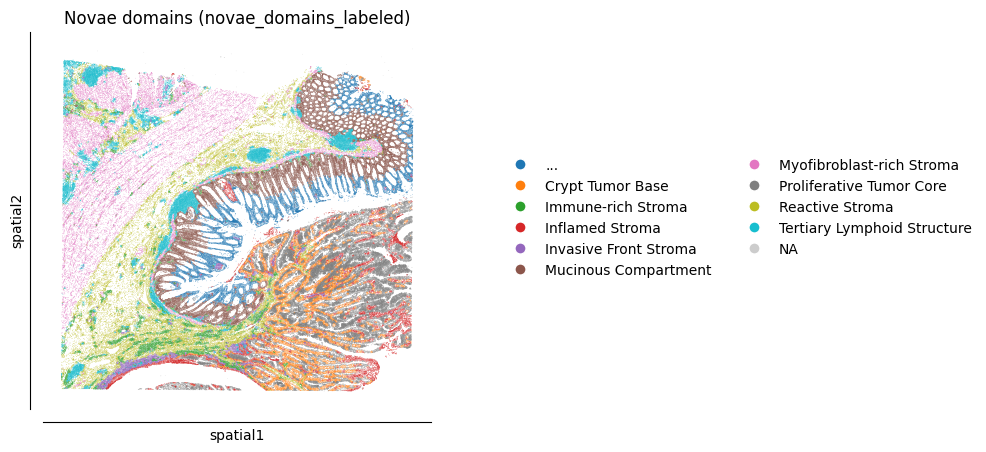

In [28]:
adata.obs["novae_domains_labeled"] = adata.obs["novae_domains_res1"].map(df_labels["label"])

novae.plot.domains(adata, obs_key="novae_domains_labeled")

### Other domain descriptions

The above domain descriptions are only examples; feel free to go further to characterize your domains better and cross-check them with the literature.


## Acknowledgment

Thanks to Lucas Rebuffet for reviewing the automated labeling and providing the biological insights from this tutorial.
